In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
import json
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("fivethirtyeight")
import branca.colormap as cm
import folium
import geopandas as gpd
import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn import linear_model
from sklearn import metrics
from statsmodels.formula.api import ols

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#For tabular Data

##EDA

In [ ]:
original_path = '/content/drive/MyDrive/house_price_pred/train(1)(train(1)).csv'
new_path = '/content/drive/MyDrive/house_price_pred/training_tabular.csv'
!cp "{original_path}" "{new_path}"
print(f"File copied from {original_path} to {new_path}")

File copied from /content/drive/MyDrive/house_price_pred/train(1)(train(1)).csv to /content/drive/MyDrive/house_price_pred/training_tabular.csv


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/house_price_pred/training_tabular.csv')
display(df.head())

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             16209 non-null  int64  
 1   date           16209 non-null  object 
 2   price          16209 non-null  int64  
 3   bedrooms       16209 non-null  int64  
 4   bathrooms      16209 non-null  float64
 5   sqft_living    16209 non-null  int64  
 6   sqft_lot       16209 non-null  int64  
 7   floors         16209 non-null  float64
 8   waterfront     16209 non-null  int64  
 9   view           16209 non-null  int64  
 10  condition      16209 non-null  int64  
 11  grade          16209 non-null  int64  
 12  sqft_above     16209 non-null  int64  
 13  sqft_basement  16209 non-null  int64  
 14  yr_built       16209 non-null  int64  
 15  yr_renovated   16209 non-null  int64  
 16  zipcode        16209 non-null  int64  
 17  lat            16209 non-null  float64
 18  long  

In [ ]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,1.620900e+04,1.620900e+04,16209.00000,16209.000000,16209.000000,1.620900e+04,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000
mean,4.575771e+09,5.374703e+05,3.36782,2.113054,2073.274601,1.486767e+04,1.498828,0.006971,0.234253,3.407860,7.652971,1784.754396,288.520205,1971.152755,82.738108,98077.974767,47.560707,-122.214003,1983.152261,12735.572707
std,2.874661e+09,3.603036e+05,0.93327,0.765242,907.009491,3.882570e+04,0.543032,0.083206,0.763152,0.651553,1.171050,821.820844,438.598910,29.372698,397.861148,53.355282,0.138340,0.140093,681.905161,26933.162012
min,1.000102e+06,7.500000e+04,0.00000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.159300,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.200000e+05,3.00000,1.500000,1430.000000,5.004000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1200.000000,0.000000,1952.000000,0.000000,98033.000000,47.472500,-122.328000,1480.000000,5098.000000
50%,3.904950e+09,4.500000e+05,3.00000,2.250000,1910.000000,7.599000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.572400,-122.230000,1840.000000,7620.000000
75%,7.304301e+09,6.400000e+05,4.00000,2.500000,2550.000000,1.063100e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2200.000000,560.000000,1997.000000,0.000000,98117.000000,47.678200,-122.125000,2360.000000,10053.000000
max,9.900000e+09,7.700000e+06,33.00000,8.000000,12050.000000,1.164794e+06,3.500000,1.000000,4.000000,5.000000,13.000000,8860.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


Observations:

1. waterfront is either 0 or 1
2. sqft_above + sqft_basement = sqft_living
3. sqft_basement, view, and yr_renovated have many zero values, potentially express them as binary variables

categorical: floors, view, grade, zipcode, bathrooms, bedrooms, condition
continuous: price, sqft_living, sqft_lot, sqft_above, sqft_basement, yr_built, yr_renovated, lat, long, sqft_living15, sqft_lot15

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


no duplicated or null values

In [ ]:
df.dtypes

,0
id,int64
date,object
price,int64
bedrooms,int64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df.drop(columns=['date'], axis=1, inplace=True)

In [ ]:
df.head()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year
0,9117000170,268643,4,2.25,1810,9240,2.0,0,0,3,...,1810,0,1961,0,98055,47.4362,-122.187,1660,9240,2015
1,6700390210,245000,3,2.50,1600,2788,2.0,0,0,4,...,1600,0,1992,0,98031,47.4034,-122.187,1720,3605,2014
2,7212660540,200000,4,2.50,1720,8638,2.0,0,0,3,...,1720,0,1994,0,98003,47.2704,-122.313,1870,7455,2015
3,8562780200,352499,2,2.25,1240,705,2.0,0,0,3,...,1150,90,2009,0,98027,47.5321,-122.073,1240,750,2015
4,7760400350,232000,3,2.00,1280,13356,1.0,0,0,3,...,1280,0,1994,0,98042,47.3715,-122.074,1590,8071,2014


For Zip code

In [ ]:
zip_df = df.groupby('zipcode').agg(np.mean)
zip_df.reset_index(inplace=True)
zip_df.head()

/tmp/ipython-input-814087717.py:1: FutureWarning: The provided callable <function mean at 0x7b3671f70220> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  zip_df = df.groupby('zipcode').agg(np.mean)


,zipcode,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,year
0,98001,4.582319e+09,2.797596e+05,3.391144,2.019373,1897.243542,13117.756458,1.428044,0.000000,0.136531,...,7.284133,1722.904059,174.339483,1980.416974,43.789668,47.308544,-122.270247,1830.487085,10781.169742,2014.339483
1,98002,4.975466e+09,2.386830e+05,3.344371,1.836093,1658.543046,7534.682119,1.347682,0.000000,0.013245,...,6.708609,1550.622517,107.920530,1967.092715,26.145695,47.310100,-122.214040,1476.052980,7075.841060,2014.350993
2,98003,4.720484e+09,2.905892e+05,3.349754,2.075123,1920.354680,10506.147783,1.312808,0.000000,0.221675,...,7.546798,1645.133005,275.221675,1976.354680,19.556650,47.315188,-122.309399,1877.093596,9967.586207,2014.320197
3,98004,4.521544e+09,1.328961e+06,3.846809,2.512766,2874.446809,12901.974468,1.429787,0.004255,0.289362,...,8.600000,2397.851064,476.595745,1970.021277,195.582979,47.616949,-122.204855,2619.617021,12669.621277,2014.331915
4,98005,5.039017e+09,8.116100e+05,3.888000,2.450000,2676.664000,20496.744000,1.248000,0.000000,0.096000,...,8.456000,2131.144000,545.520000,1969.656000,64.016000,47.611266,-122.167288,2542.328000,18704.224000,2014.328000


In [ ]:
df['count'] = 1
count_zip = df.groupby('zipcode').sum()
count_zip.reset_index(inplace=True)
count_zip = count_zip[['zipcode', 'count']]
df.drop(['count'], axis = 1, inplace=True)
count_zip.head()

,zipcode,count
0,98001,271
1,98002,151
2,98003,203
3,98004,235
4,98005,125


In [ ]:
zip_df = pd.merge(zip_df, count_zip, how='left', on=['zipcode'])
zip_df.head()

,zipcode,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,year,count
0,98001,4.582319e+09,2.797596e+05,3.391144,2.019373,1897.243542,13117.756458,1.428044,0.000000,0.136531,...,1722.904059,174.339483,1980.416974,43.789668,47.308544,-122.270247,1830.487085,10781.169742,2014.339483,271
1,98002,4.975466e+09,2.386830e+05,3.344371,1.836093,1658.543046,7534.682119,1.347682,0.000000,0.013245,...,1550.622517,107.920530,1967.092715,26.145695,47.310100,-122.214040,1476.052980,7075.841060,2014.350993,151
2,98003,4.720484e+09,2.905892e+05,3.349754,2.075123,1920.354680,10506.147783,1.312808,0.000000,0.221675,...,1645.133005,275.221675,1976.354680,19.556650,47.315188,-122.309399,1877.093596,9967.586207,2014.320197,203
3,98004,4.521544e+09,1.328961e+06,3.846809,2.512766,2874.446809,12901.974468,1.429787,0.004255,0.289362,...,2397.851064,476.595745,1970.021277,195.582979,47.616949,-122.204855,2619.617021,12669.621277,2014.331915,235
4,98005,5.039017e+09,8.116100e+05,3.888000,2.450000,2676.664000,20496.744000,1.248000,0.000000,0.096000,...,2131.144000,545.520000,1969.656000,64.016000,47.611266,-122.167288,2542.328000,18704.224000,2014.328000,125


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'sqft_living'}>],
       [<Axes: title={'center': 'sqft_lot'}>,
        <Axes: title={'center': 'floors'}>,
        <Axes: title={'center': 'waterfront'}>,
        <Axes: title={'center': 'view'}>,
        <Axes: title={'center': 'condition'}>],
       [<Axes: title={'center': 'grade'}>,
        <Axes: title={'center': 'sqft_above'}>,
        <Axes: title={'center': 'sqft_basement'}>,
        <Axes: title={'center': 'yr_built'}>,
        <Axes: title={'center': 'yr_renovated'}>],
       [<Axes: title={'center': 'zipcode'}>,
        <Axes: title={'center': 'lat'}>,
        <Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'sqft_living15'}>,
        <Axes: title={'center': 'sqft_lot15'}>],
       [<Axes: title={'center': 'year'}>, <Axes: >, <Axes: >, <Axes: >,
       

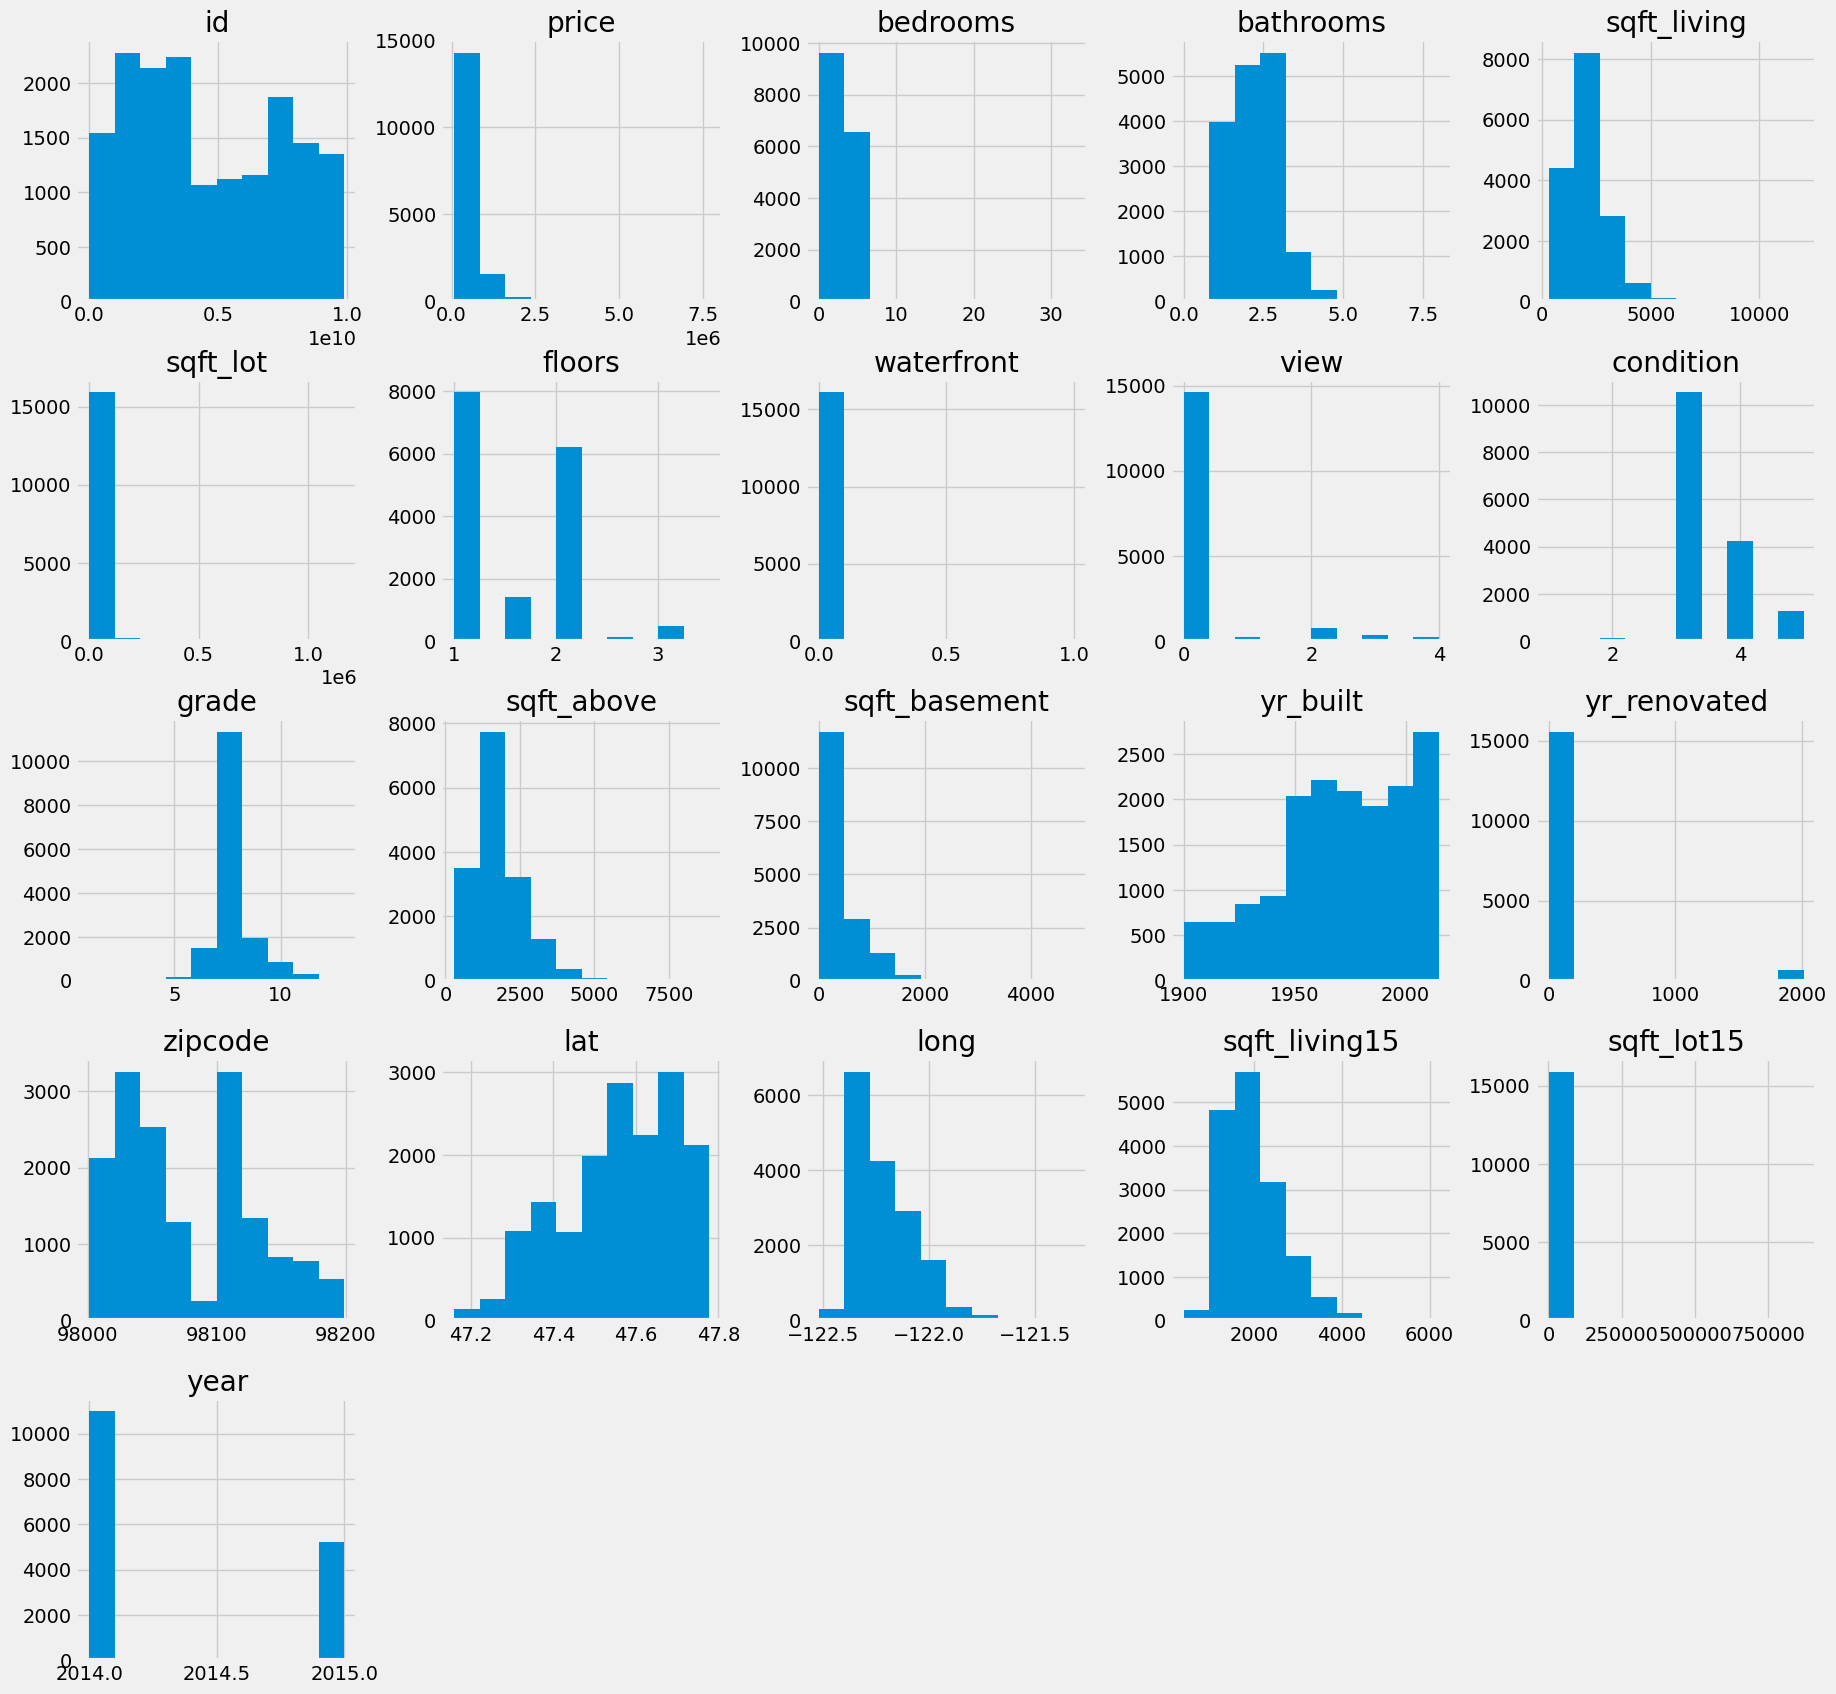

In [ ]:
df.hist(figsize=(20, 20))

In [ ]:
feat_cat = df[['view', 'condition', 'grade', 'waterfront', 'floors', 'bedrooms', 'bathrooms', 'zipcode']]
feat_con = df[['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15', 'yr_built', 'yr_renovated', 'lat', 'long']]

In [ ]:
col_con = feat_con.columns
col_cat = feat_cat.columns

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packa

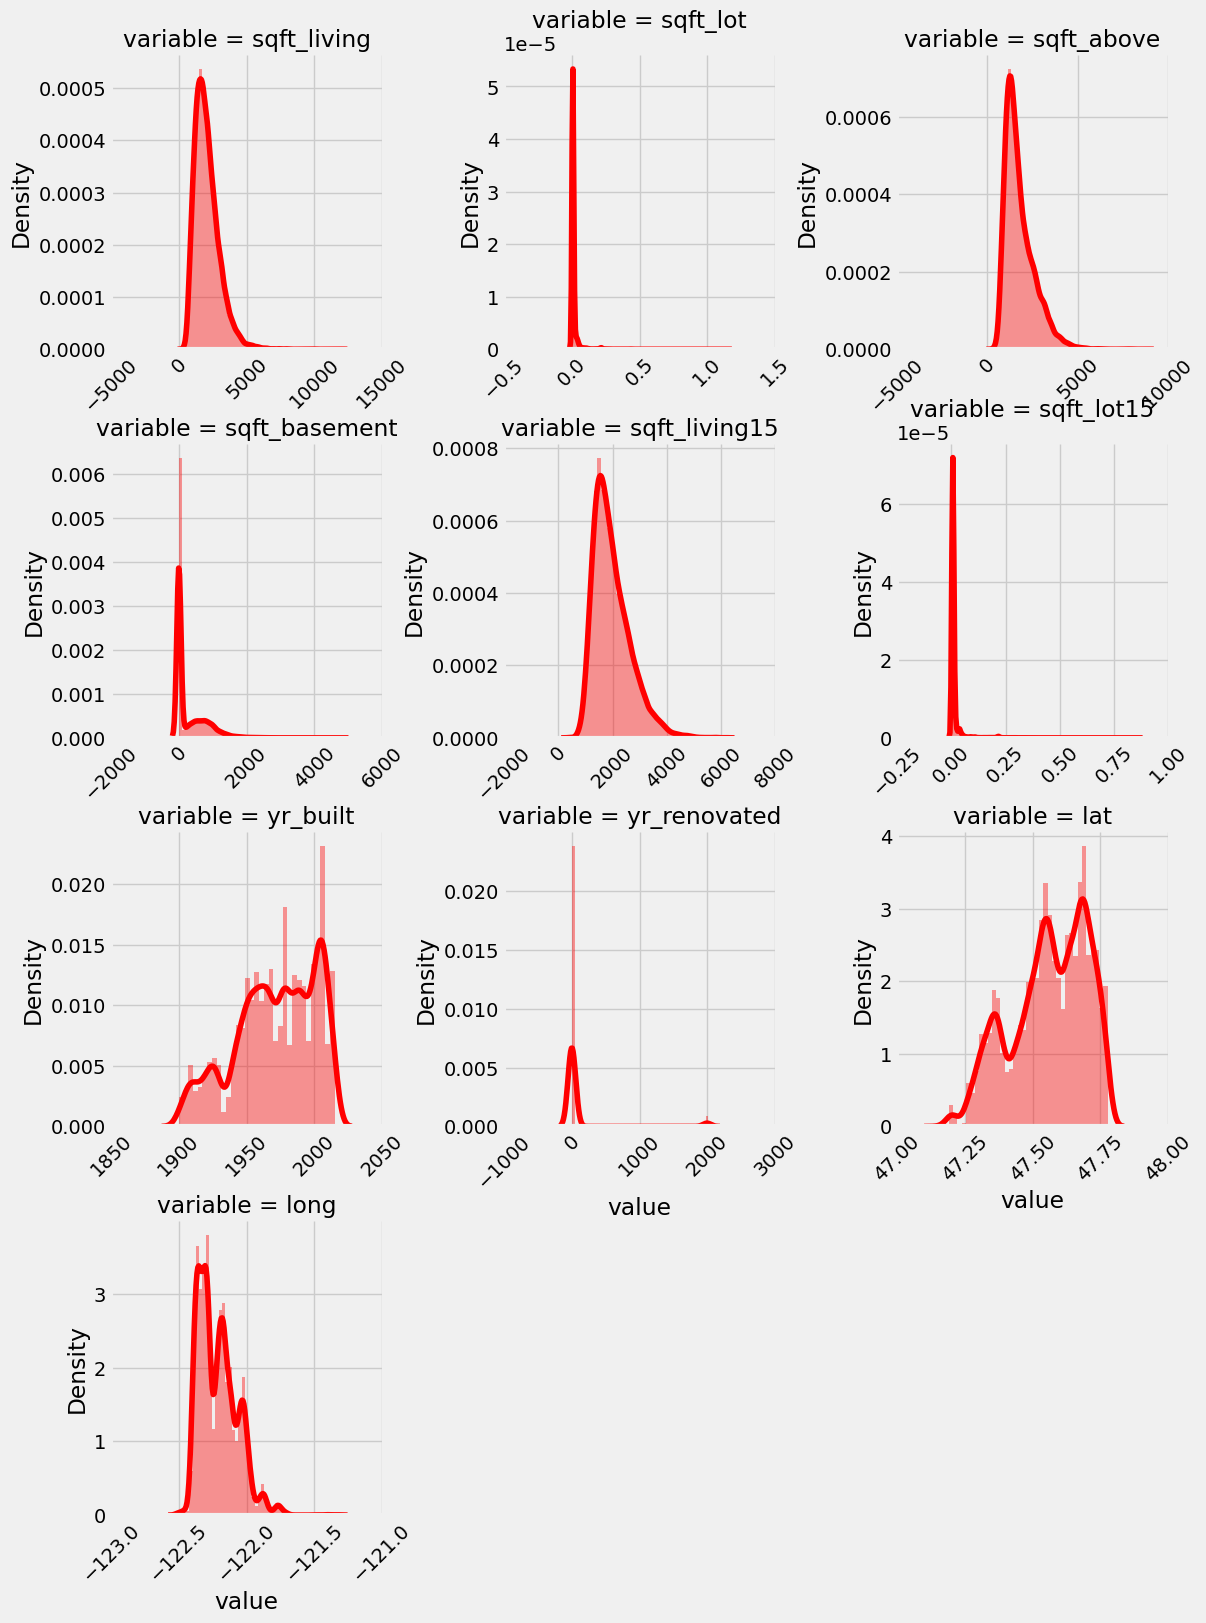

In [ ]:
con_1 = pd.melt(df, value_vars = col_con)
g = sns.FacetGrid(con_1, col='variable', col_wrap=3, sharex=False, sharey=False, height=4)
g = g.map(sns.distplot, 'value', color='r')
g.set_xticklabels(rotation=45)

Observations:

sqft_living, sqft_above, and sqft_living15 are skewed to the right- use log transformation.
sqft_lot, sqft_lot15, sqft_basement, and yr_renovated have a lot of zero values, maybe create a discrete binary variable for some of them..

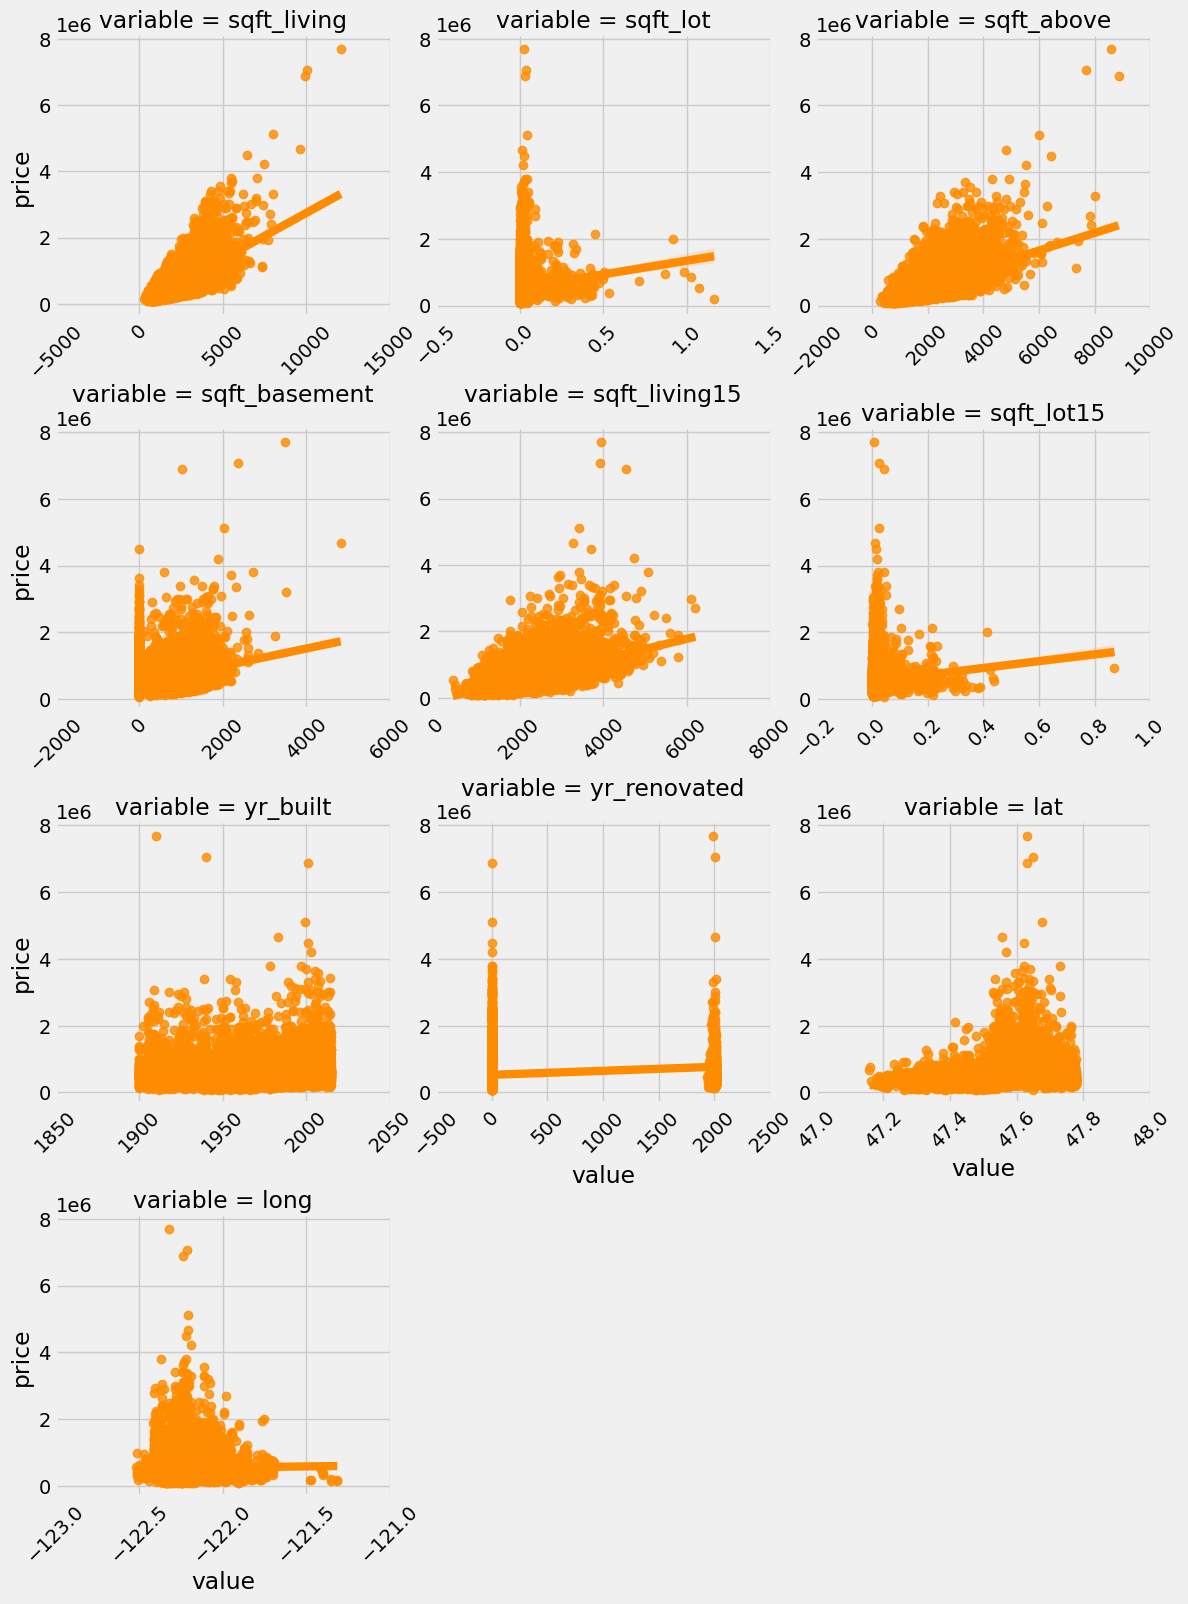

In [ ]:
con_2 = pd.melt(df, id_vars='price', value_vars=col_con)
g = sns.FacetGrid(con_2, col='variable', col_wrap=3, sharex=False, sharey=False, height=4)
g = g.map(sns.regplot, 'value', 'price', color='darkorange')
g.set_xticklabels(rotation=45)

Observations

1. yr renovated should be considered as discrete
2. hard to see relationship of lat, long, and yr_built to price

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


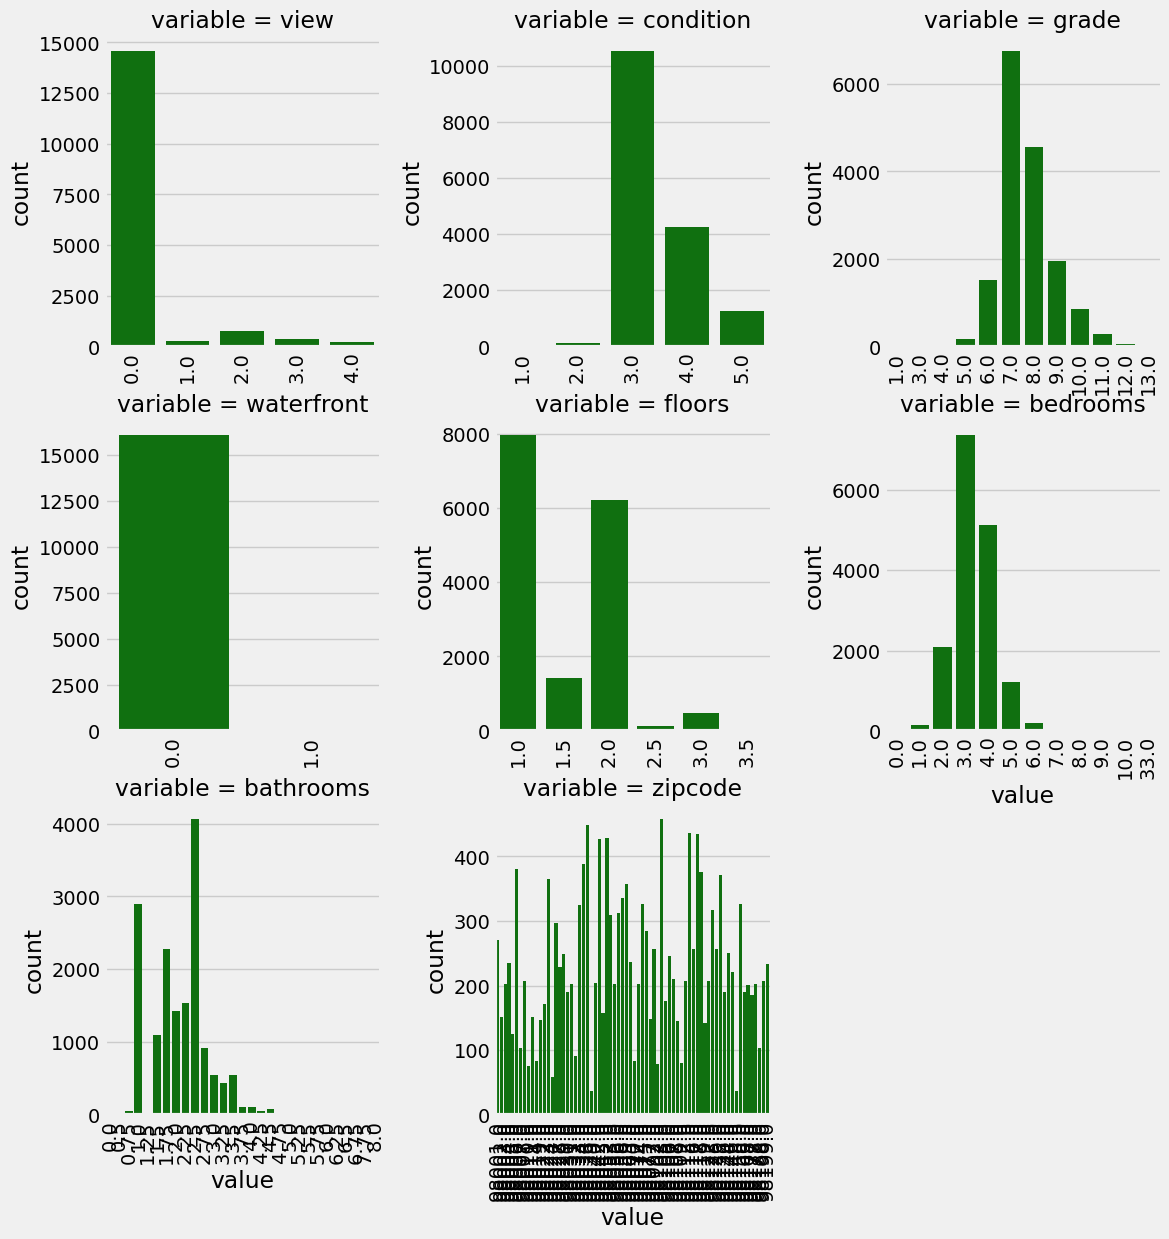

In [ ]:
cat_1 = pd.melt(df, value_vars=col_cat)
g = sns.FacetGrid(cat_1, col='variable', col_wrap=3, sharex=False, sharey=False, height=4)
g = g.map(sns.countplot, 'value', color='g')
g.set_xticklabels(rotation=90)

Observations:

- large number of zero values for waterfont and
- view
bedrooms and bathrooms have right-skewed data

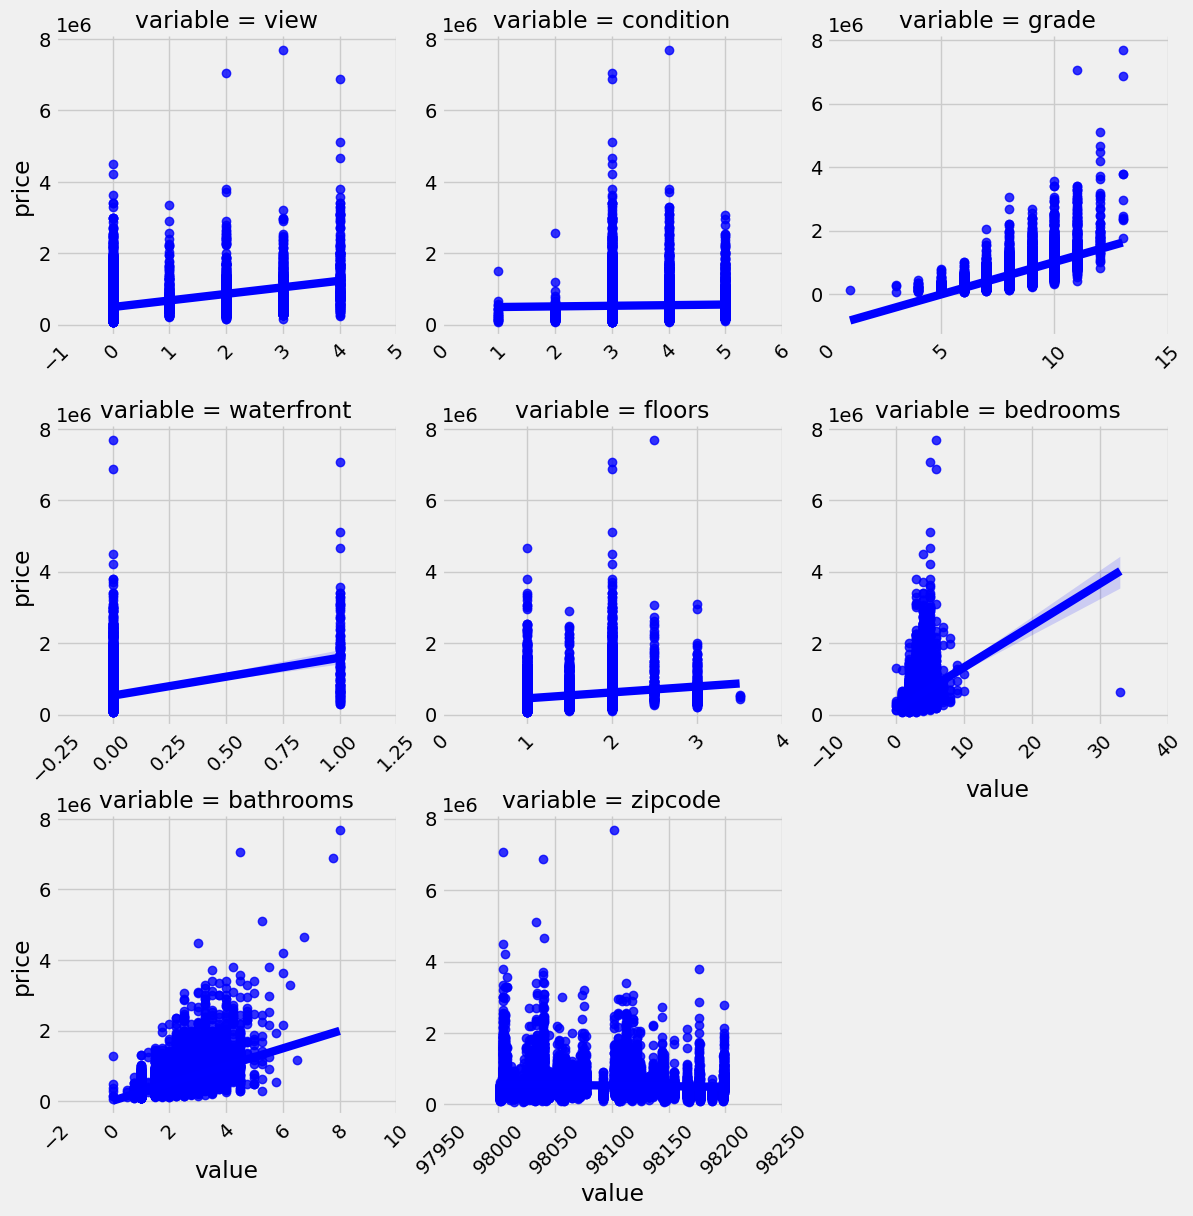

In [ ]:
con_2 = pd.melt(df, id_vars='price', value_vars=col_cat)
g = sns.FacetGrid(con_2, col='variable', col_wrap=3, sharex=False, sharey=False, height=4)
g = g.map(sns.regplot, 'value', 'price', color='blue')
g.set_xticklabels(rotation=45)

Observations:

1. stronger relationship: bedrooms vs. price, grade vs. price
2. waterfront and view have correlation with price
little relationship between zipcode, condition, and floor

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


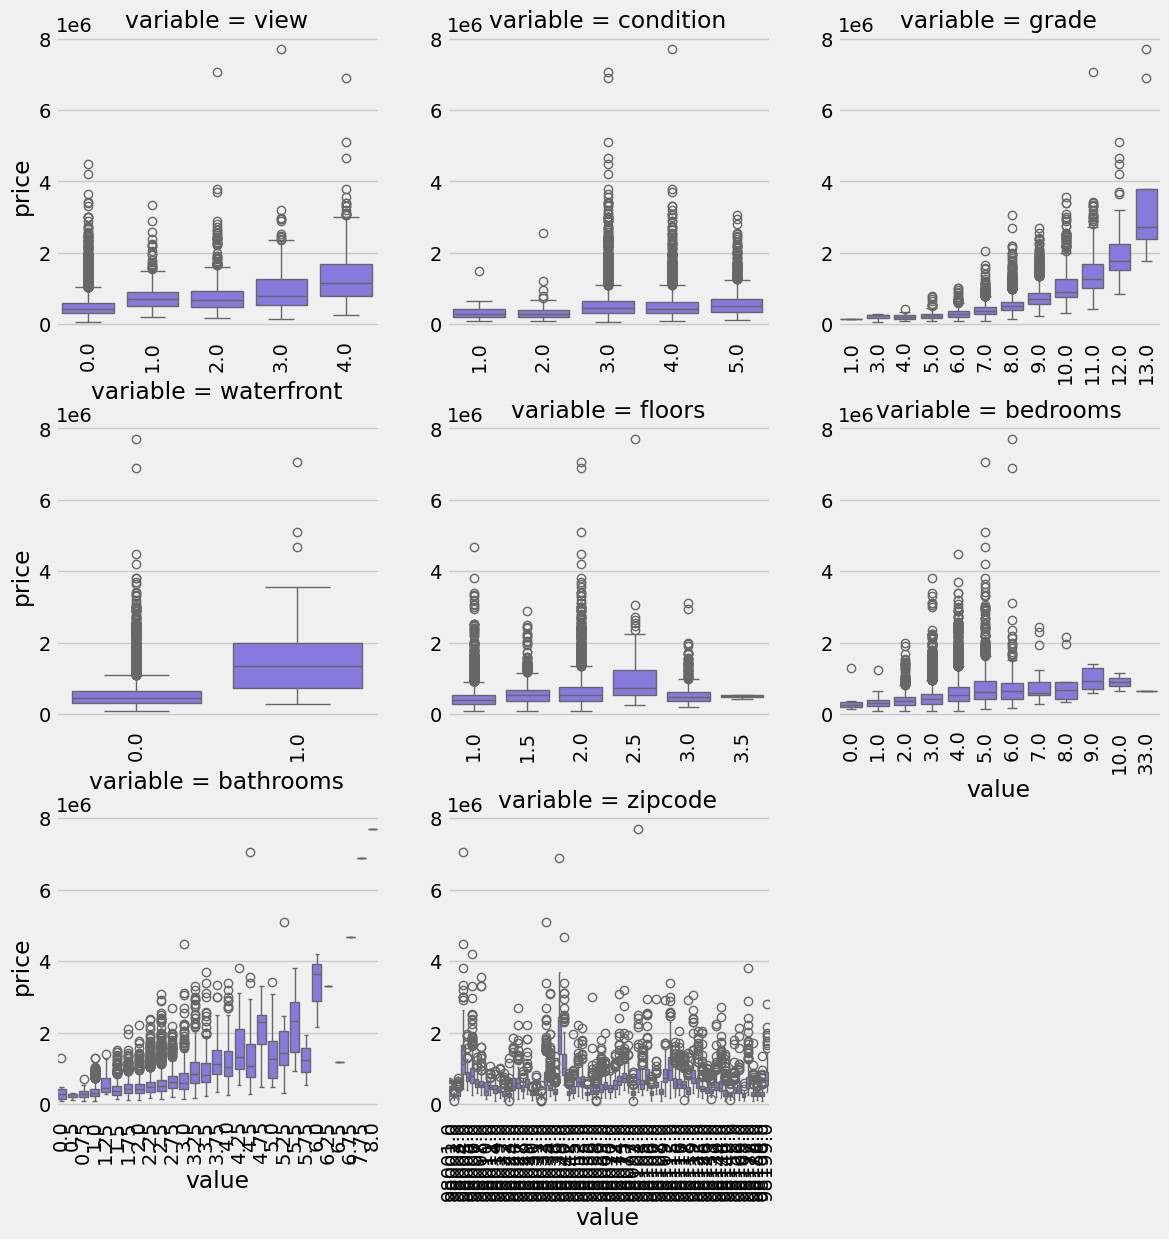

In [ ]:
cat_3 = pd.melt(df, id_vars='price', value_vars=col_cat)
g = sns.FacetGrid(cat_3, col='variable', col_wrap=3, sharex=False, sharey=False, height=4)
g = g.map(sns.boxplot, 'value', 'price', color='mediumslateblue')
g.set_xticklabels(rotation=90)

1. strong exponential relationship in the mean values for number of bathrooms and grade
little correlation with mean views, perhaps express as binary variable
2. potentially replace outliers with the mean for grade and bathrooms

<Axes: xlabel='zipcode', ylabel='median price'>

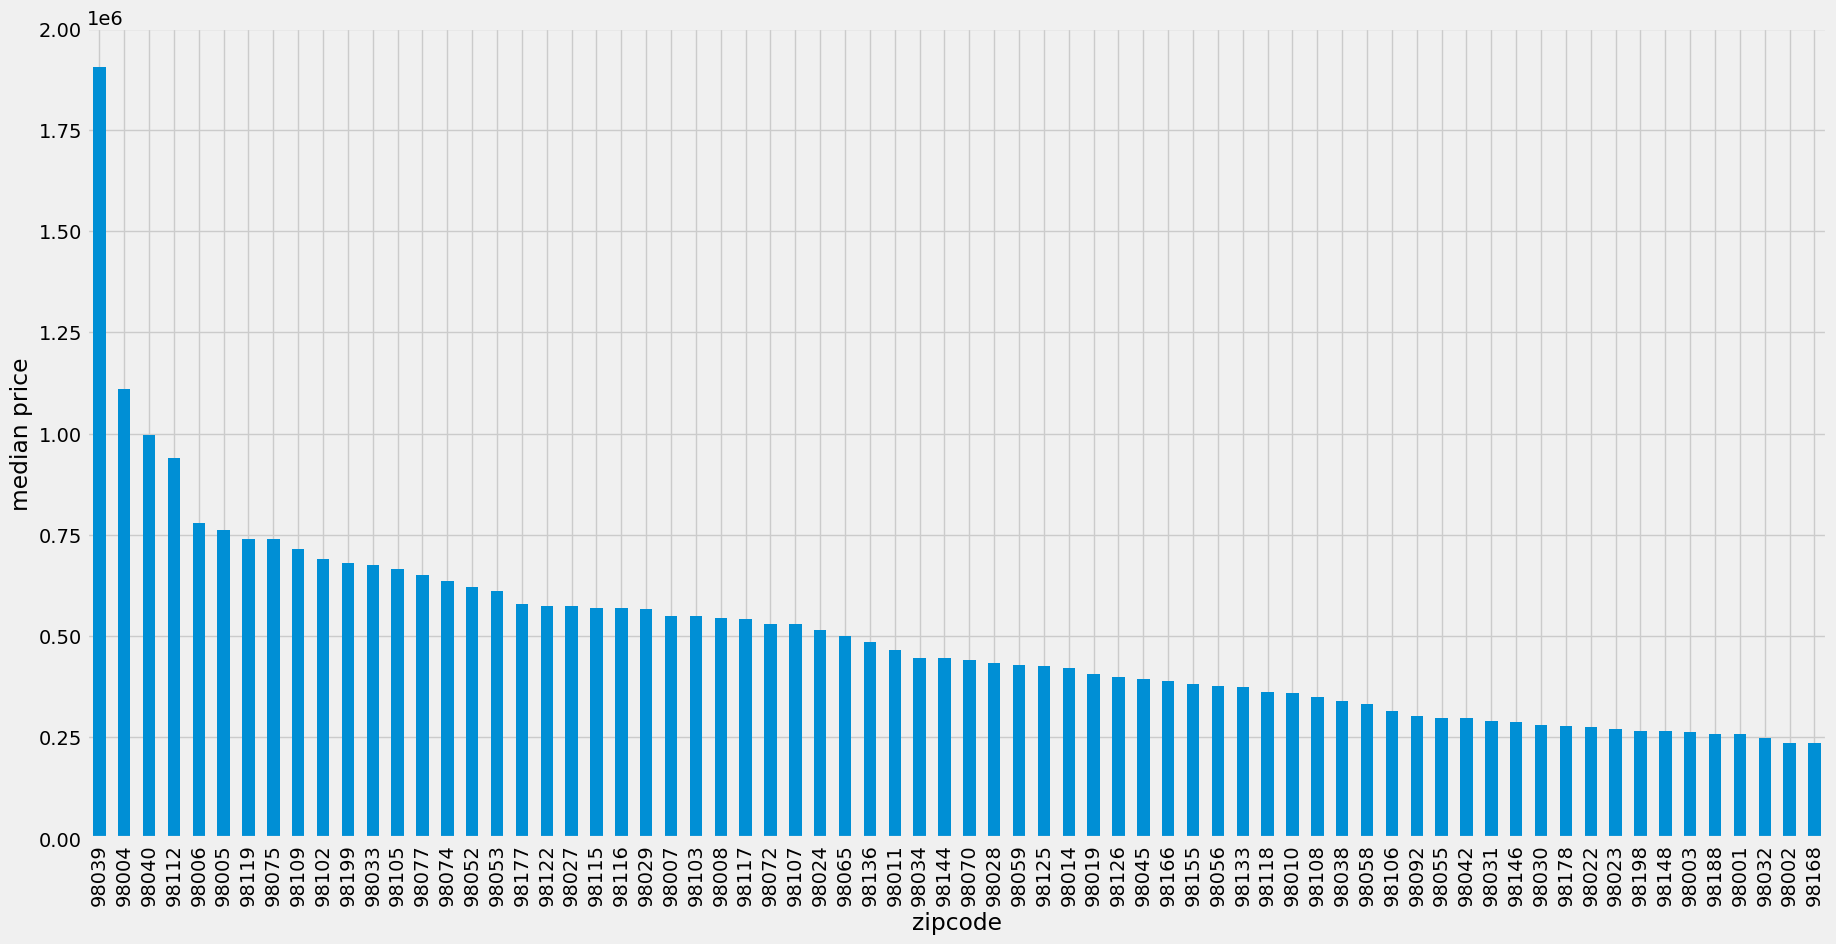

In [ ]:
df_zipcode = df.groupby(['zipcode']).price.median().sort_values(ascending=False)
plt.figure(figsize=(20,10))
plt.ylabel('median price')
df_zipcode.plot(kind='bar')

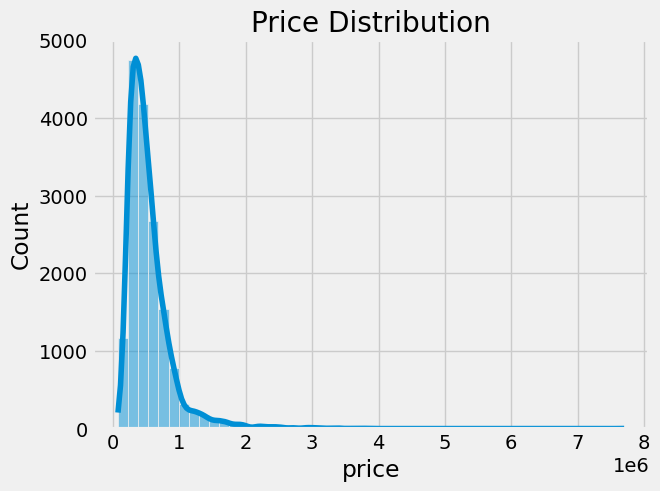

In [ ]:
plt.figure()
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()


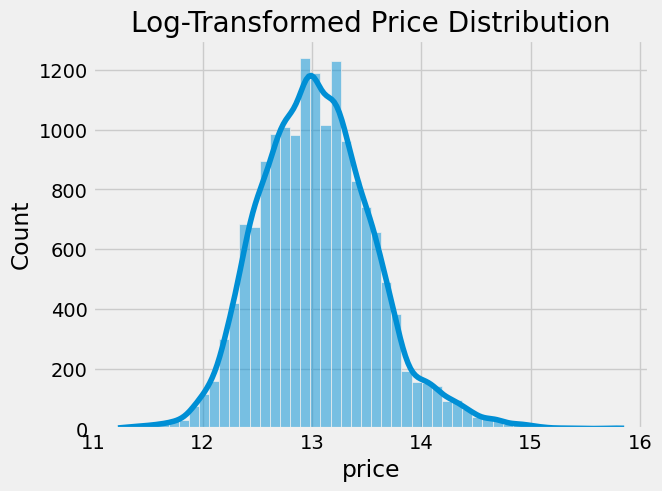

In [ ]:
# Log-transformed price
plt.figure()
sns.histplot(np.log1p(df["price"]), bins=50, kde=True)
plt.title("Log-Transformed Price Distribution")
plt.show()


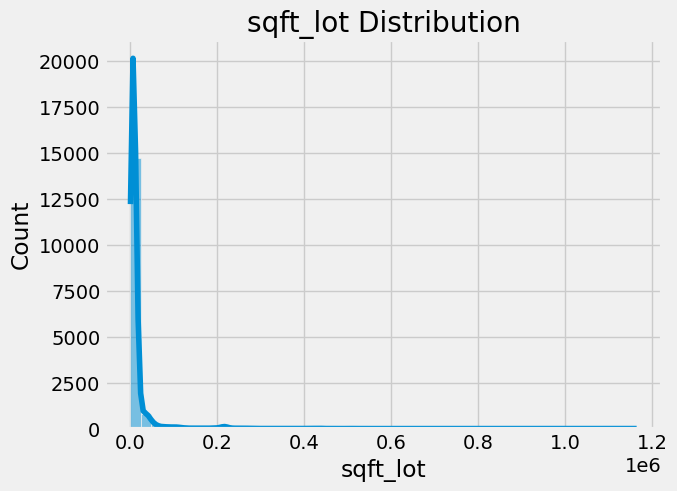

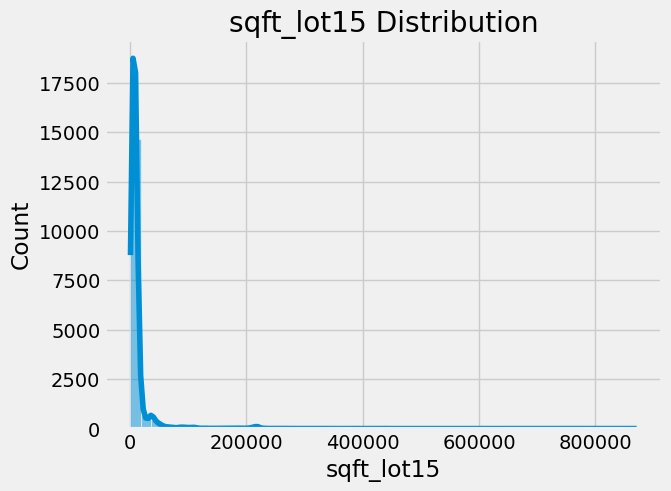

In [ ]:
skewed = ["sqft_lot", "sqft_lot15"]

for col in skewed:
    plt.figure()
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
    plt.show()


In [ ]:
# IQR-based outlier boundaries
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

print("Lower bound:", Q1 - 1.5 * IQR)
print("Upper bound:", Q3 + 1.5 * IQR)


Lower bound: -160000.0
Upper bound: 1120000.0


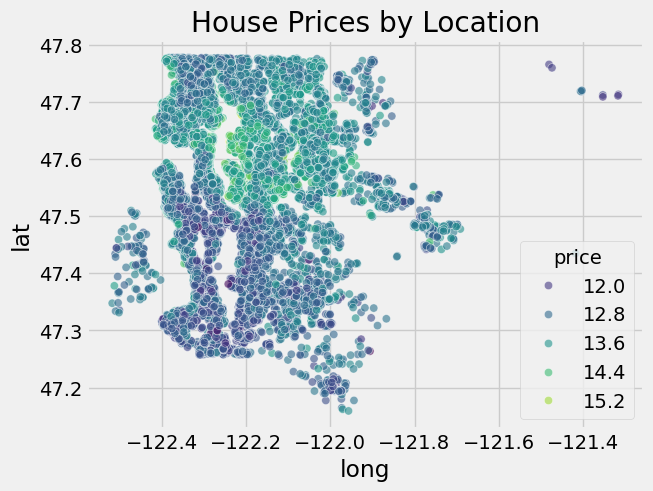

In [ ]:
plt.figure()
sns.scatterplot(
    x=df["long"], y=df["lat"],
    hue=np.log1p(df["price"]),
    palette="viridis", alpha=0.6
)
plt.title("House Prices by Location")
plt.show()


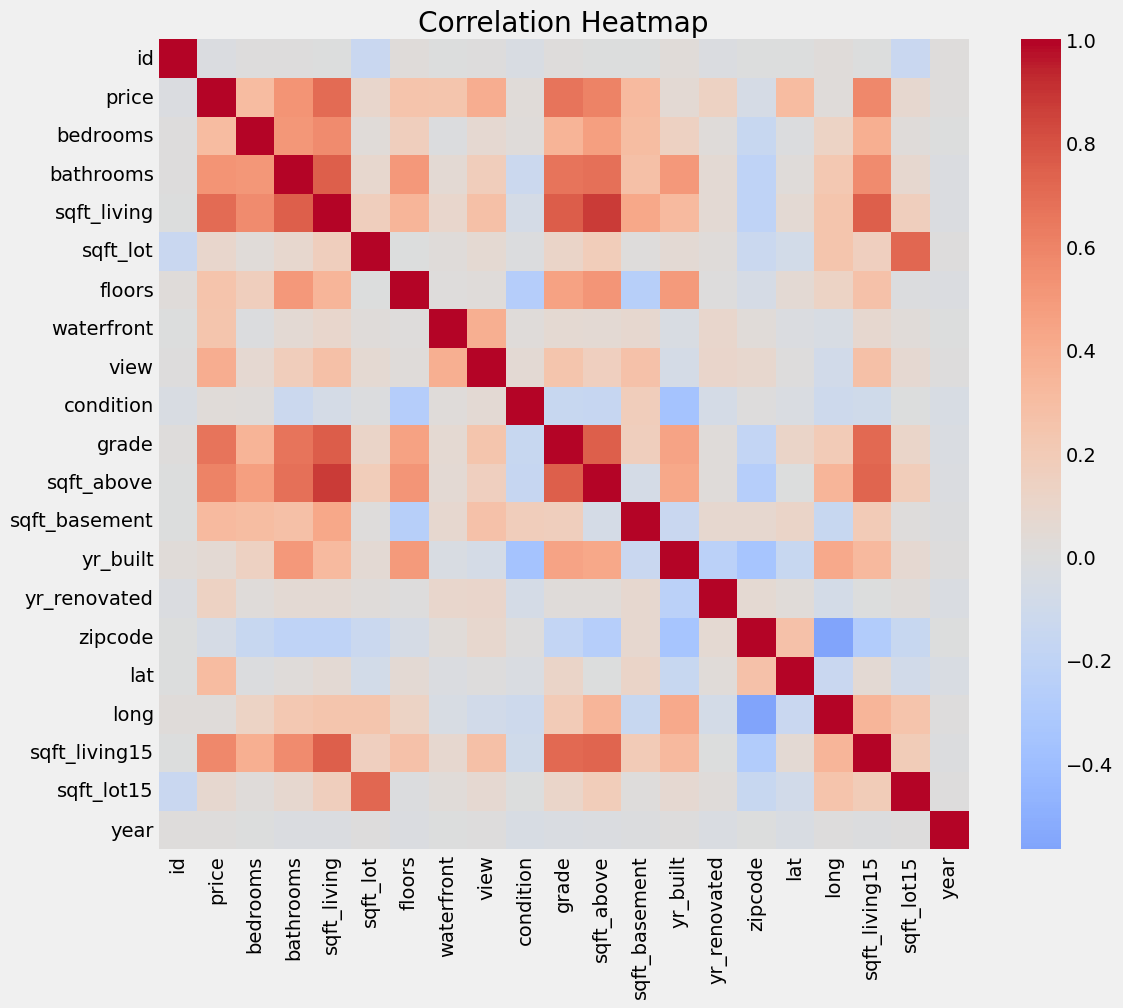

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Correlation with price
corr["price"].sort_values(ascending=False)


,price
price,1.000000
sqft_living,0.700933
grade,0.664266
sqft_above,0.602648
sqft_living15,0.581781
bathrooms,0.525487
view,0.390534
sqft_basement,0.320301
lat,0.310008
bedrooms,0.304454


EDA SUMMARY:
- Price is right-skewed → log transformation recommended.
- sqft_living and grade show strongest correlation with price.
- Lot size features are highly skewed → log transform needed.
-Price has a strong correlation with sqft_living and grade
-Price has medium correlation with bedrooms, sqft_above, sqft_living15
-Price has low correlation with bedrooms, floors, sqft_basement, latitude
-Price has no significant relationship with sqft_lot, yr_built, long, sqft_lot15




##Data Cleaning

In [ ]:
df.drop(['id'], inplace=True, axis=1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year
0,268643,4,2.25,1810,9240,2.0,0,0,3,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240,2015
1,245000,3,2.50,1600,2788,2.0,0,0,4,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605,2014
2,200000,4,2.50,1720,8638,2.0,0,0,3,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455,2015
3,352499,2,2.25,1240,705,2.0,0,0,3,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750,2015
4,232000,3,2.00,1280,13356,1.0,0,0,3,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071,2014


In [ ]:
df.bedrooms.value_counts()

,count
bedrooms,
3,7380
4,5128
2,2098
5,1213
6,197
1,142
7,26
8,9
0,8


33 bedrooms is an outlier.. we re removing it..

In [ ]:
df.replace({'bedrooms': {33: 3}}, inplace=True)

In [ ]:
df.grade.value_counts()

,count
grade,
7,6761
8,4563
9,1943
6,1511
10,861
11,286
5,183
12,63
4,24


##Feature Engi

In [ ]:
df['sale_age'] = df['year'] - df[['yr_built', 'yr_renovated']].max(axis=1)
df.sale_age.value_counts(ascending=False)

,count
sale_age,
9,390
0,383
10,360
8,360
11,348
...,...
113,18
-1,14
115,14


negative values has to be removed

In [ ]:
df.replace({'sale_age': {-1: 0}}, inplace=True)

In [ ]:
df['age'] = df['year'] - df.yr_built

In [ ]:
df.age.value_counts()

,count
age,
9,368
8,336
10,334
11,321
0,318
...,...
113,19
81,18
115,17


In [ ]:
df.replace({'age': {-1: 0}}, inplace=True)

In [ ]:
df['renovated'] = df.yr_renovated.apply(lambda x: x if x==0 else 1)
df['basement'] = df.sqft_basement.apply(lambda x: x if x==0 else 1)
df['viewed'] = df.view.apply(lambda x: x if x==0 else 1)

df.drop(['yr_built', 'yr_renovated', 'year', 'sqft_basement', 'view'], inplace=True, axis=1)

In [ ]:
print(df.basement.value_counts())
print(df.viewed.value_counts())
print(df.renovated.value_counts())

basement
0    9882
1    6327
Name: count, dtype: int64
viewed
0    14604
1     1605
Name: count, dtype: int64
renovated
0    15537
1      672
Name: count, dtype: int64


In [ ]:
df.corr()["price"].sort_values(ascending=False)

,price
price,1.000000
sqft_living,0.700933
grade,0.664266
sqft_above,0.602648
sqft_living15,0.581781
bathrooms,0.525487
viewed,0.355841
bedrooms,0.313804
lat,0.310008
floors,0.251428


In [ ]:
df["log_sqft_lot"] = np.log1p(df["sqft_lot"])
df["log_sqft_lot15"] = np.log1p(df["sqft_lot15"])


In [ ]:
df.corr()["price"].sort_values(ascending=False)

,price
price,1.000000
sqft_living,0.700933
grade,0.664266
sqft_above,0.602648
sqft_living15,0.581781
bathrooms,0.525487
viewed,0.355841
bedrooms,0.313804
lat,0.310008
floors,0.251428


There is a significant increase in corr when log is considered

In [ ]:
df.drop(['sqft_lot','sqft_lot15'], inplace=True, axis=1)

In [ ]:
df.corr()["price"].sort_values(ascending=False)

,price
price,1.000000
sqft_living,0.700933
grade,0.664266
sqft_above,0.602648
sqft_living15,0.581781
bathrooms,0.525487
viewed,0.355841
bedrooms,0.313804
lat,0.310008
floors,0.251428


In [ ]:
col_cat

Index(['view', 'condition', 'grade', 'waterfront', 'floors', 'bedrooms',
       'bathrooms', 'zipcode'],
      dtype='object')

In [ ]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront',
       'condition', 'grade', 'sqft_above', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sale_age', 'age', 'renovated', 'basement', 'viewed',
       'log_sqft_lot', 'log_sqft_lot15'],
      dtype='object')

In [ ]:
# Grab indices of columns for creating dummy variables and create dataframe with dummy variables
dum_feat = df[['bedrooms', 'bathrooms', 'floors', 'condition', 'grade', 'zipcode']]
dum_index = dum_feat.columns
# To prevent what they call the dummy variable trap (related to multicollinearity), drop one of the dummy variable, as well as  the original categorical variable used in creating the dummy variables
df_dum = pd.get_dummies(data=dum_feat, columns=dum_index, drop_first=True, prefix=['bdr', 'bth', 'flr', 'cnd', 'grd', 'zip'])
df_dum.head()

,bdr_1,bdr_2,bdr_3,bdr_4,bdr_5,bdr_6,bdr_7,bdr_8,bdr_9,bdr_10,...,zip_98146,zip_98148,zip_98155,zip_98166,zip_98168,zip_98177,zip_98178,zip_98188,zip_98198,zip_98199
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:

# # Polynomial features
# poly = PolynomialFeatures(degree=2, include_bias=False)
# poly_data = poly.fit_transform(poly_feat)

# # Correct method for sklearn >= 1.0
# poly_columns = poly.get_feature_names_out(poly_feat.columns)

# # Create DataFrame
# df_poly = pd.DataFrame(poly_data, columns=poly_columns, index=poly_feat.index)

# Combine with dummy variables
X = pd.concat([df, inplace=True, axis=1], df_dum, axis=1)

X.head()


,bdr_1,bdr_2,bdr_3,bdr_4,bdr_5,bdr_6,bdr_7,bdr_8,bdr_9,bdr_10,...,zip_98146,zip_98148,zip_98155,zip_98166,zip_98168,zip_98177,zip_98178,zip_98188,zip_98198,zip_98199
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
Y= df['price']

##Modelling

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
X = X.copy()   # your final feature matrix
y = Y.copy()   # price

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
X_train

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,condition,grade,sqft_above,zipcode,...,zip_98146,zip_98148,zip_98155,zip_98166,zip_98168,zip_98177,zip_98178,zip_98188,zip_98198,zip_98199
4140,286700,3,1.00,1220,1.0,0,3,6,1220,98065,...,False,False,False,False,False,False,False,False,False,False
1510,400000,2,2.00,2010,1.5,0,3,7,1450,98108,...,False,False,False,False,False,False,False,False,False,False
6706,715000,4,2.50,2570,2.0,0,3,9,2570,98074,...,False,False,False,False,False,False,False,False,False,False
11009,1039000,4,2.25,2740,1.0,0,5,10,1980,98125,...,False,False,False,False,False,False,False,False,False,False
6554,1862000,4,5.25,5240,2.0,0,3,10,5240,98024,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13418,899000,4,2.25,2290,1.0,0,4,8,1550,98008,...,False,False,False,False,False,False,False,False,False,False
5390,820000,4,2.50,3670,2.0,0,3,10,3670,98075,...,False,False,False,False,False,False,False,False,False,False
860,375000,3,1.00,1130,1.5,0,3,7,1130,98118,...,False,False,False,False,False,False,False,False,False,False
15795,539000,3,2.25,1280,2.0,0,3,8,1080,98107,...,False,False,False,False,False,False,False,False,False,False


## training on traditional models

In [ ]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10, random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
    ),

    "KNN": KNeighborsRegressor(n_neighbors=10)
}


In [ ]:
results = []

for name, model in models.items():

    # Scale only when needed
    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression", "KNN"]:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        pipeline = model

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })


In [ ]:
results_df = pd.DataFrame(results).sort_values(
    by="R2 Score", ascending=False
)

results_df


## Xgboost Regressor

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

results_df.loc[len(results_df)] = [
    "XGBoost",
    np.sqrt(mean_squared_error(y_test, y_pred)),
    mean_absolute_error(y_test, y_pred),
    r2_score(y_test, y_pred)
]

results_df.sort_values("R2 Score", ascending=False)


In [ ]:
X_tr= X_train
X_tt= X_test
y_tr= y_train
y_tt= y_test

In [ ]:
X_tr.drop(['price'],inplace=True, axis=1)
X_tt.drop(['price'],inplace=True, axis=1)

In [ ]:
X.value_counts()

bdr_1  bdr_2  bdr_3  bdr_4  bdr_5  bdr_6  bdr_7  bdr_8  bdr_9  bdr_10  bth_0.5  bth_0.75  bth_1.0  bth_1.25  bth_1.5  bth_1.75  bth_2.0  bth_2.25  bth_2.5  bth_2.75  bth_3.0  bth_3.25  bth_3.5  bth_3.75  bth_4.0  bth_4.25  bth_4.5  bth_4.75  bth_5.0  bth_5.25  bth_5.5  bth_5.75  bth_6.0  bth_6.25  bth_6.5  bth_6.75  bth_7.75  bth_8.0  flr_1.5  flr_2.0  flr_2.5  flr_3.0  flr_3.5  cnd_2  cnd_3  cnd_4  cnd_5  grd_3  grd_4  grd_5  grd_6  grd_7  grd_8  grd_9  grd_10  grd_11  grd_12  grd_13  zip_98002  zip_98003  zip_98004  zip_98005  zip_98006  zip_98007  zip_98008  zip_98010  zip_98011  zip_98014  zip_98019  zip_98022  zip_98023  zip_98024  zip_98027  zip_98028  zip_98029  zip_98030  zip_98031  zip_98032  zip_98033  zip_98034  zip_98038  zip_98039  zip_98040  zip_98042  zip_98045  zip_98052  zip_98053  zip_98055  zip_98056  zip_98058  zip_98059  zip_98065  zip_98070  zip_98072  zip_98074  zip_98075  zip_98077  zip_98092  zip_98102  zip_98103  zip_98105  zip_98106  zip_98107  zip_98108  zip_98109  zip_98112  zip_98115  zip_98116  zip_98117  zip_98118  zip_98119  zip_98122  zip_98125  zip_98126  zip_98133  zip_98136  zip_98144  zip_98146  zip_98148  zip_98155  zip_98166  zip_98168  zip_98177  zip_98178  zip_98188  zip_98198  zip_98199
False  False  True   False  False  False  False  False  False  False   False    False     False    False     False    False     False    False     True     False     False    False     False    False     False    False     False    False     False    False     False    False     False    False     False    False     False     False    False    True     False    False    False    False  True   False  False  False  False  False  False  False  True   False  False   False   False   False   False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      True       False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False        52
              False  True   False  False  False  False  False  False   False    False     False    False     False    False     False    False     True     False     False    False     False    False     False    False     False    False     False    False     False    False     False    False     False    False     False     False    False    True     False    False    False    False  True   False  False  False  False  False  False  True   False  False  False   False   False   False   False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      True       False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False      False        48
                                                                                                                                                                                                                                                 

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_tr, y_tr)

y_tr_pred = lr.predict(X_tr)
y_tt_pred = lr.predict(X_tt)

print("Train R2:", r2_score(y_tr, y_tr_pred))
print("Test R2:", r2_score(y_tt, y_tt_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_tt, y_tt_pred)))

Train R2: 0.8518722829957004
Test R2: 0.8249576957110553
Test RMSE: 148208.68904705823


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

kb = SelectKBest(score_func=f_regression, k=20)
X_tr_kb = kb.fit_transform(X_tr, y_tr)
X_tt_kb = kb.transform(X_tt)

selected_features = X_tr.columns[kb.get_support()]
print("Selected Features:", list(selected_features))

lr_kb = LinearRegression()
lr_kb.fit(X_tr_kb, y_tr)

y_tt_pred_kb = lr_kb.predict(X_tt_kb)

print("Test R2:", r2_score(y_tt, y_tt_pred_kb))
print("Test RMSE:", np.sqrt(mean_squared_error(y_tt, y_tt_pred_kb)))


Selected Features: ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'grade', 'sqft_above', 'lat', 'sqft_living15', 'viewed', 'bth_1.0', 'flr_2.0', 'grd_7', 'grd_9', 'grd_10', 'grd_11', 'grd_12', 'grd_13', 'zip_98004', 'zip_98039']
Test R2: 0.7228251619796775
Test RMSE: 186500.09445972144


In [ ]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rfecv.fit(X_tr, y_tr)

print("Optimal number of features:", rfecv.n_features_)

X_tr_rfe = X_tr.loc[:, rfecv.support_]
X_tt_rfe = X_tt.loc[:, rfecv.support_]

lr_rfe = LinearRegression()
lr_rfe.fit(X_tr_rfe, y_tr)

y_tt_pred_rfe = lr_rfe.predict(X_tt_rfe)

print("Test R2:", r2_score(y_tt, y_tt_pred_rfe))
print("Test RMSE:", np.sqrt(mean_squared_error(y_tt, y_tt_pred_rfe)))


Optimal number of features: 146
Test R2: 0.8249576957110553
Test RMSE: 148208.68904705823


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {"ridge__alpha": np.arange(1, 500, 10)}

ridge_cv = GridSearchCV(
    ridge_pipe,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=5
)

ridge_cv.fit(X_tr, y_tr)

print("Optimal Alpha:", ridge_cv.best_params_)

y_tt_pred_ridge = ridge_cv.predict(X_tt)

print("Test RMSE:", np.sqrt(mean_squared_error(y_tt, y_tt_pred_ridge)))


Optimal Alpha: {'ridge__alpha': np.int64(1)}
Test RMSE: 146523.28282324423


In [ ]:
from sklearn.linear_model import Lasso

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000))
])

param_grid = {"lasso__alpha": np.arange(100, 1000, 50)}

lasso_cv = GridSearchCV(
    lasso_pipe,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=5
)

lasso_cv.fit(X_tr, y_tr)

print("Optimal Alpha:", lasso_cv.best_params_)

y_tt_pred_lasso = lasso_cv.predict(X_tt)

print("Test RMSE:", np.sqrt(mean_squared_error(y_tt, y_tt_pred_lasso)))


Optimal Alpha: {'lasso__alpha': np.int64(100)}
Test RMSE: 146708.45090326638


In [ ]:
from sklearn.linear_model import LassoLarsIC

lasso_aic = LassoLarsIC(criterion="aic")
lasso_bic = LassoLarsIC(criterion="bic")

lasso_aic.fit(X_tr, y_tr)
lasso_bic.fit(X_tr, y_tr)

print("AIC Alpha:", lasso_aic.alpha_)
print("BIC Alpha:", lasso_bic.alpha_)


AIC Alpha: 1.5402203956080671
BIC Alpha: 12.58189742230685


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_tr, y_tr)

print("Train R2:", dt.score(X_tr, y_tr))
print("Test R2:", dt.score(X_tt, y_tt))


Train R2: 0.9999401553893293
Test R2: 0.7346186879575036


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": [5, 10, 15, 20]}

dt_cv = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_mean_squared_error",
    cv=5
)

dt_cv.fit(X_tr, y_tr)

print("Best depth:", dt_cv.best_params_)

y_tt_pred_dt = dt_cv.predict(X_tt)
print("Test RMSE:", np.sqrt(mean_squared_error(y_tt, y_tt_pred_dt)))


Best depth: {'max_depth': 10}
Test RMSE: 171041.29847714107


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10]
}

rf_rs = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=10,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

rf_rs.fit(X_tr, y_tr)

print("Best RF Params:", rf_rs.best_params_)

y_tt_pred_rf = rf_rs.predict(X_tt)
print("Test RMSE:", np.sqrt(mean_squared_error(y_tt, y_tt_pred_rf)))


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_tr, y_tr)
y_tt_pred_gbr = gbr.predict(X_tt)

print("Test RMSE:", np.sqrt(mean_squared_error(y_tt, y_tt_pred_gbr)))


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Baseline LR", "SelectKBest LR", "RFECV LR",
        "Ridge", "Lasso", "Decision Tree",
        "Random Forest", "GBRT"
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_tt, y_tt_pred)),
        np.sqrt(mean_squared_error(y_tt, y_tt_pred_kb)),
        np.sqrt(mean_squared_error(y_tt, y_tt_pred_rfe)),
        np.sqrt(mean_squared_error(y_tt, y_tt_pred_ridge)),
        np.sqrt(mean_squared_error(y_tt, y_tt_pred_lasso)),
        np.sqrt(mean_squared_error(y_tt, y_tt_pred_dt)),
        np.sqrt(mean_squared_error(y_tt, y_tt_pred_rf)),
        np.sqrt(mean_squared_error(y_tt, y_tt_pred_gbr))
    ]
})

results.sort_values("Test RMSE")
